In [1]:
import pandas as pd
import numpy as np
import cobra

In [2]:
# loading both datasets 
#geo_df  = pd.read_csv("GSE50760_norm_counts_TPM_GRCh38.p13_NCBI.tsv", sep="\t", index_col=0
tcga_data_path = "/Users/valentinreateguirangel/dissertation_project/data/TCGA_LIver/TCGA-LIHC.star_tpm.tsv.gz.tsv"
tcga_df = pd.read_csv(tcga_data_path, sep="\t", index_col=0, compression="gzip")

## Data exploration

In [4]:
#TCGA size
print(tcga_df.shape)

(60660, 424)


In [5]:
# Checkin for NA values 
print(tcga_df.isna().sum().sum())

0


In [6]:
# Checking for duplicates 
print(tcga_df.index.duplicated().sum())    

0


## Data standarization 

In [8]:
# Remove vesrion numbers .00
tcga_df.index = tcga_df.index.str.split('.').str[0]

In [9]:
# Checkinf for duplicates
print(tcga_df.index.duplicated().sum())   

44


In [10]:
# Get the duplicated index values
duplicated_indices = tcga_df.index[tcga_df.index.duplicated()]

In [11]:
# Get all rows with duplicated indices (including the first occurrence)
duplicates_df = tcga_df.loc[tcga_df.index.isin(duplicated_indices)]

In [12]:
# Getting only duplicated rows for processing 
duplicate_rows = tcga_df.loc[duplicated_indices]

In [13]:
# Keeping only non "0"
non_zero_duplicates = duplicate_rows.loc[~(duplicate_rows == 0).all(axis=1)]

In [14]:
# Droping duplicates with all "0"
tcga_df_cleaned = tcga_df.drop(index= duplicated_indices)
tcga_df_cleaned = pd.concat([tcga_df_cleaned, non_zero_duplicates])

In [15]:
# Sorting out index
tcga_df_cleaned = tcga_df_cleaned.sort_index()

## Data Exploration (2) how rich a cell line is 

In [17]:
# Checking for duplicates
print(tcga_df_cleaned.index.duplicated().sum())    

0


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate gene detection rate for each sample
def calculate_sample_richness(df):
    richness_metrics = pd.DataFrame(index=df.columns)

    # 1. Detection rate
    richness_metrics['detection_rate'] = (df > 0).sum() / len(df) * 100

    # 2. Meaningful expression (TPM > 1)
    richness_metrics['meaningful_genes'] = (df > 1).sum()
    richness_metrics['meaningful_rate'] = richness_metrics['meaningful_genes'] / len(df) * 100

    # 3. High expression (TPM > 10)
    richness_metrics['high_expr_genes'] = (df > 10).sum()
    richness_metrics['high_expr_rate'] = richness_metrics['high_expr_genes'] / len(df) * 100

    # 4. Library size
    richness_metrics['library_size'] = df.sum()

    # 5. Median expression (non-zero)
    richness_metrics['median_nonzero'] = df.replace(0, np.nan).median()

    # 6. Expression diversity (Shannon index)
    def shannon_diversity(col):
        probs = col[col > 0] / col[col > 0].sum()
        return -np.sum(probs * np.log2(probs))
    
    richness_metrics['expression_diversity'] = df.apply(shannon_diversity)

    # 7. Low expression penalty (TPM < 0.1)
    richness_metrics['low_expr_rate'] = (df < 0.1).sum() / len(df) * 100

    # 8. Final richness score with penalty
    # You can tweak the weights (e.g., -0.3 means strong penalty for low-expressed genes)
    richness_metrics['richness_score'] = (
        richness_metrics['detection_rate'] * 0.4 +
        richness_metrics['meaningful_rate'] * 0.4 +
        richness_metrics['high_expr_rate'] * 0.2 -
        richness_metrics['low_expr_rate'] * 0.3  # penalty for low expression
    )

    return richness_metrics

# Apply to your data
richness = calculate_sample_richness(tcga_df)

# Sort by richness score
richness_sorted = richness.sort_values('richness_score', ascending=False)
print("Top 10 richest samples:")
print(richness_sorted.head(10))

print(f"\nRichness score range: {richness['richness_score'].min():.2f} - {richness['richness_score'].max():.2f}")

Top 10 richest samples:
                  detection_rate  meaningful_genes  meaningful_rate  \
TCGA-G3-A7M9-01A       62.281569             19668        32.423343   
TCGA-G3-A7M6-01A       58.458622             19288        31.796901   
TCGA-CC-A1HT-01A       57.268381             17378        28.648203   
TCGA-CC-5263-01A       56.979888             16555        27.291461   
TCGA-BC-4073-01B       57.865150             15783        26.018793   
TCGA-DD-A4NH-01A       55.557204             16527        27.245302   
TCGA-ZP-A9D2-01A       53.763600             17697        29.174085   
TCGA-ED-A97K-01A       53.269041             17877        29.470821   
TCGA-ED-A5KG-01A       52.911309             17847        29.421365   
TCGA-CC-A7II-01A       55.150016             16189        26.688098   

                  high_expr_genes  high_expr_rate  library_size  \
TCGA-G3-A7M9-01A              100        0.164853  77633.465068   
TCGA-G3-A7M6-01A               88        0.145071  76417.298

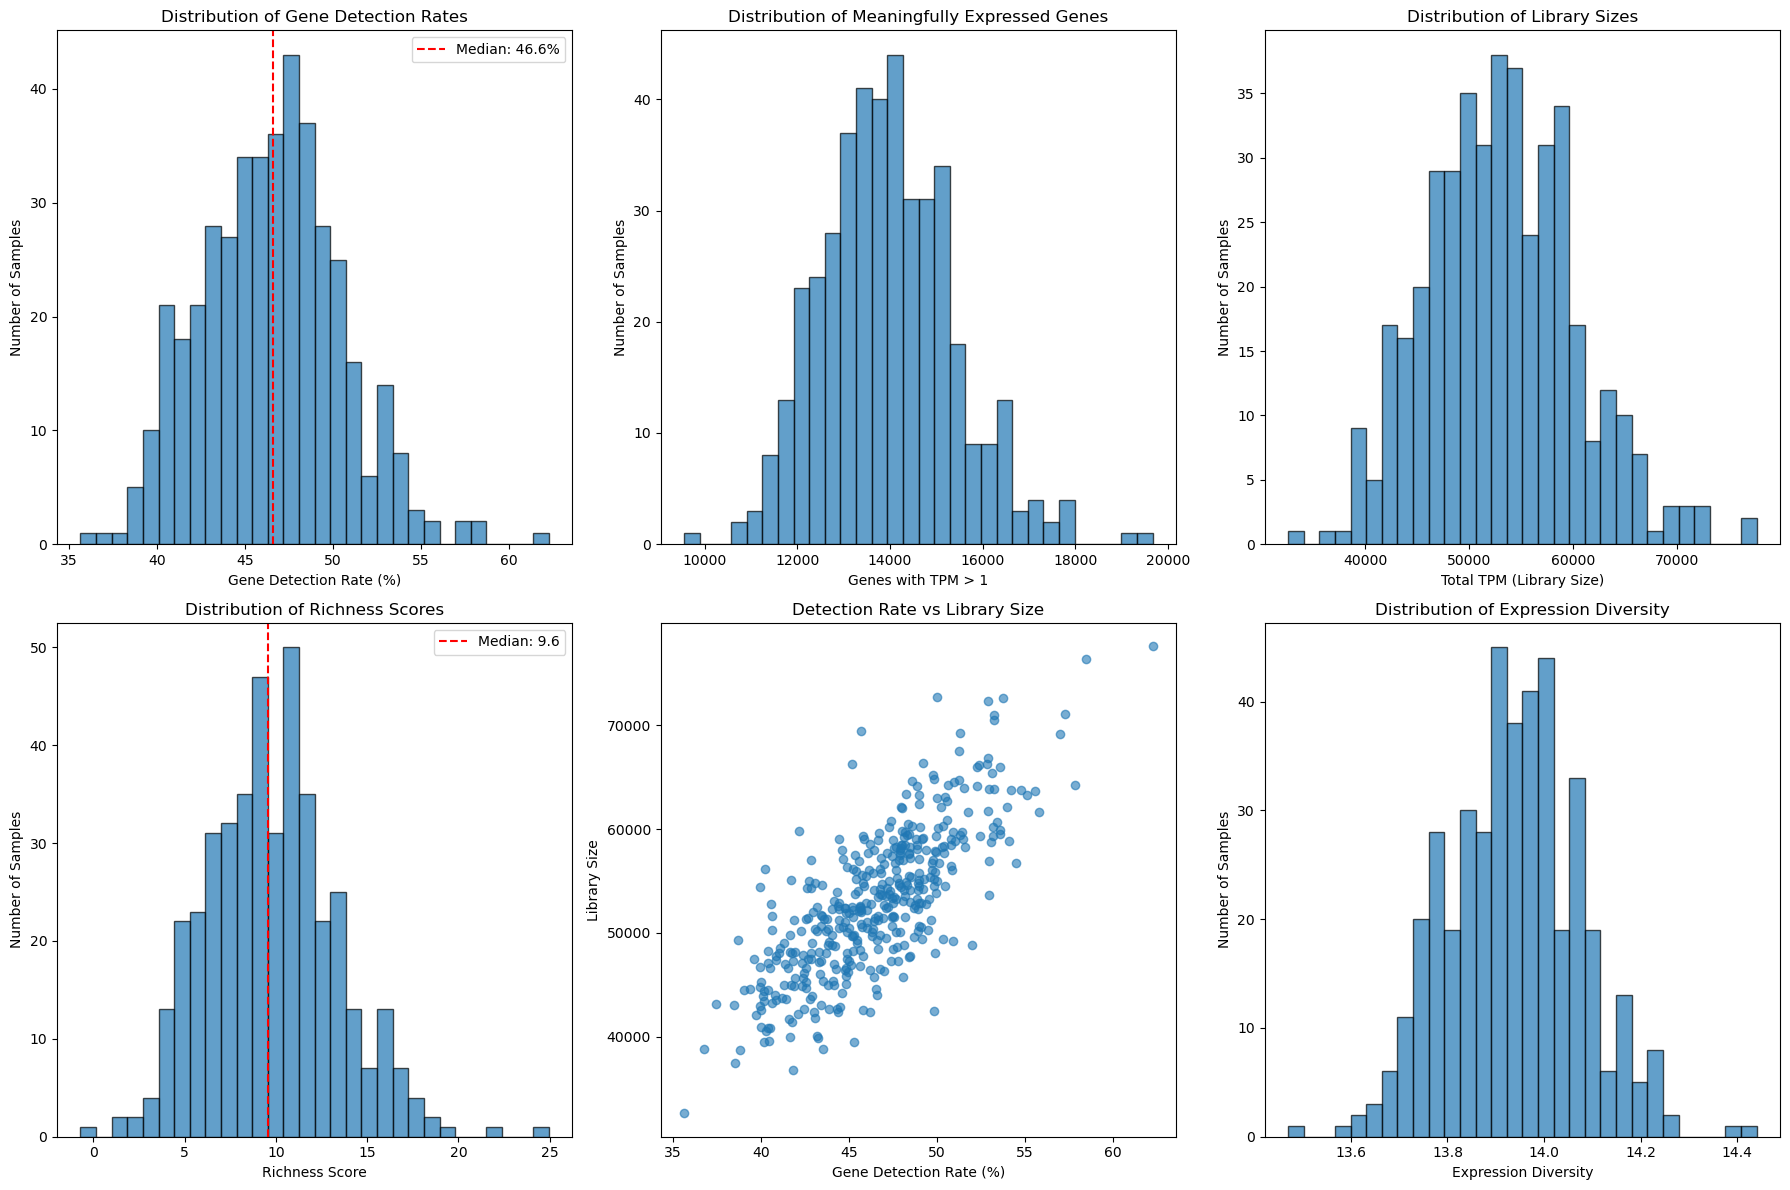

In [19]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Detection rate distribution
axes[0,0].hist(richness['detection_rate'], bins=30, alpha=0.7, edgecolor='black')
axes[0,0].set_xlabel('Gene Detection Rate (%)')
axes[0,0].set_ylabel('Number of Samples')
axes[0,0].set_title('Distribution of Gene Detection Rates')
axes[0,0].axvline(richness['detection_rate'].median(), color='red', linestyle='--', 
                  label=f'Median: {richness["detection_rate"].median():.1f}%')
axes[0,0].legend()

# Meaningful genes (TPM > 1)
axes[0,1].hist(richness['meaningful_genes'], bins=30, alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Genes with TPM > 1')
axes[0,1].set_ylabel('Number of Samples')
axes[0,1].set_title('Distribution of Meaningfully Expressed Genes')

# Library size
axes[0,2].hist(richness['library_size'], bins=30, alpha=0.7, edgecolor='black')
axes[0,2].set_xlabel('Total TPM (Library Size)')
axes[0,2].set_ylabel('Number of Samples')
axes[0,2].set_title('Distribution of Library Sizes')

# Richness score
axes[1,0].hist(richness['richness_score'], bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Richness Score')
axes[1,0].set_ylabel('Number of Samples')
axes[1,0].set_title('Distribution of Richness Scores')
axes[1,0].axvline(richness['richness_score'].median(), color='red', linestyle='--',
                  label=f'Median: {richness["richness_score"].median():.1f}')
axes[1,0].legend()

# Scatter: Detection rate vs Library size
axes[1,1].scatter(richness['detection_rate'], richness['library_size'], alpha=0.6)
axes[1,1].set_xlabel('Gene Detection Rate (%)')
axes[1,1].set_ylabel('Library Size')
axes[1,1].set_title('Detection Rate vs Library Size')

# Expression diversity
axes[1,2].hist(richness['expression_diversity'], bins=30, alpha=0.7, edgecolor='black')
axes[1,2].set_xlabel('Expression Diversity')
axes[1,2].set_ylabel('Number of Samples')
axes[1,2].set_title('Distribution of Expression Diversity')

plt.tight_layout()
plt.show()

In [20]:
# Select only top X samples 

def select_top_n_samples(richness_df, top_n=300):
    # Sort the DataFrame by richness_score in descending order
    sorted_df = richness_df.sort_values('richness_score', ascending=False)

    # Select the top N sample names (column names from your expression matrix)
    top_sample_ids = sorted_df.head(top_n).index.tolist()

    print(f"Selected top {top_n} samples with richness scores:")
    print(sorted_df.head(top_n)[['richness_score']])

    return top_sample_ids

In [21]:
# Select only top samples
top_samples = select_top_n_samples(richness, top_n=300)
filtered_tcga_top = tcga_df[top_samples]

Selected top 300 samples with richness scores:
                  richness_score
TCGA-G3-A7M9-01A       24.950544
TCGA-G3-A7M6-01A       22.010551
TCGA-CC-A1HT-01A       19.192549
TCGA-CC-5263-01A       18.609133
TCGA-BC-4073-01B       18.117376
...                          ...
TCGA-ZP-A9CV-01A        7.828553
TCGA-FV-A3I1-11A        7.801682
TCGA-G3-A5SL-01A        7.774151
TCGA-BC-A10X-11A        7.765579
TCGA-BC-A10S-01A        7.746291

[300 rows x 1 columns]


In [22]:
tcga_df_cleaned = filtered_tcga_top

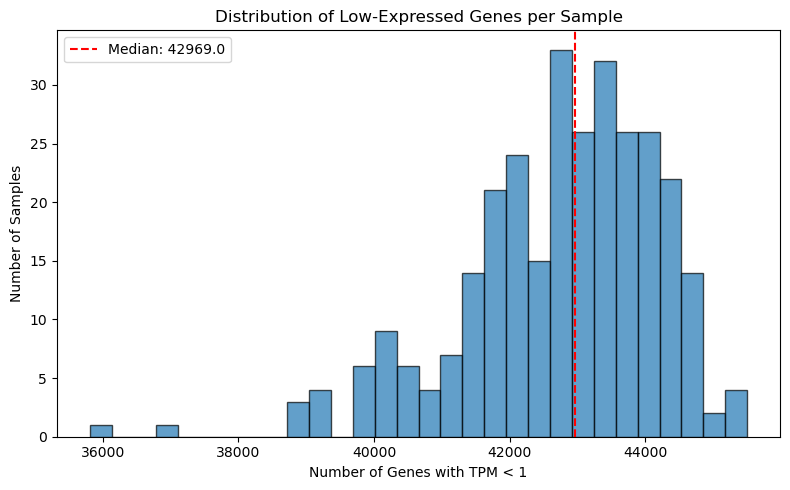

In [23]:
# Cheking low expressed genes 
low_expr_counts = (tcga_df_cleaned < 0.5).sum()


# Plot as histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(low_expr_counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Genes with TPM < 1')
plt.ylabel('Number of Samples')
plt.title('Distribution of Low-Expressed Genes per Sample')
plt.axvline(low_expr_counts.median(), color='red', linestyle='--', 
            label=f'Median: {low_expr_counts.median()}')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print(tcga_df_cleaned.shape)

(60660, 300)


## Relabeling TCGA data

In [26]:
# Relabeling function
def label_tcga(col):
    try:
        parts = col.split('-')
        if len(parts) < 4:
            return f"TCGA_{col}"
        sample_code = parts[3][:2]
        condition = "Tumor" if sample_code == "01" else "Healthy" if sample_code == "11" else "Other"
        patient_id = parts[2]  
        return f"TCGA_{condition}_{patient_id}"
    except:
        return f"TCGA_Unknown_{col}"

In [27]:
tcga_labeled = tcga_df_cleaned.copy()
tcga_labeled.columns = [label_tcga(col) for col in tcga_labeled.columns]

In [28]:
print (tcga_labeled.head())
print(tcga_labeled.index.duplicated().sum())   

                 TCGA_Tumor_A7M9  TCGA_Tumor_A7M6  TCGA_Tumor_A1HT  \
Ensembl_ID                                                           
ENSG00000000003         5.534890         6.543265         5.900683   
ENSG00000000005         0.058386         0.000000         0.153287   
ENSG00000000419         7.312033         6.653106         7.591039   
ENSG00000000457         3.361389         3.712948         2.778902   
ENSG00000000460         3.683629         2.626766         2.677057   

                 TCGA_Tumor_5263  TCGA_Tumor_4073  TCGA_Tumor_A4NH  \
Ensembl_ID                                                           
ENSG00000000003         4.729591         4.013909         5.626366   
ENSG00000000005         0.000000         0.052416         0.115033   
ENSG00000000419         6.180003         6.249121         6.713913   
ENSG00000000457         3.188433         2.681337         3.218347   
ENSG00000000460         3.170101         2.136126         2.391025   

                 T

## Model  TCGA
TCGA, it will be relabeled and then converted in to single vectors for iMat

In [30]:
tcga_only= tcga_labeled.copy()

In [31]:
# Relabeling using previous function def.label_tcga 
tcga_only.columns = [label_tcga(col) for col in tcga_only.columns]

Check for duble values also analysing the values dristribution fo the gene expressions 

In [33]:
# Spliting healhty to tumour, spliting by column label
tcga_tumor_df   = tcga_only.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_df = tcga_only.loc[:, tcga_only.columns.str.contains("Healthy")]

In [34]:
print (tcga_tumor_df.shape)
print (tcga_healthy_df.shape)

(60660, 282)
(60660, 16)


#### Data Visualization 

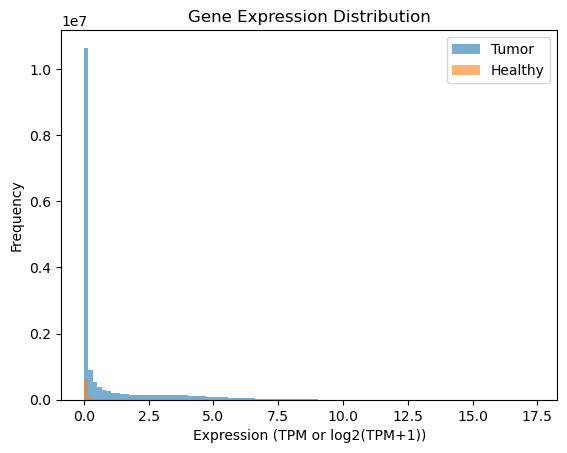

In [36]:
import matplotlib.pyplot as plt

# Flatten the values into one array per dataset
tumor_vals = tcga_tumor_df.values.flatten()
healthy_vals = tcga_healthy_df.values.flatten()

plt.hist(tumor_vals, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_vals, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Expression (TPM or log2(TPM+1))")
plt.ylabel("Frequency")
plt.title("Gene Expression Distribution")
plt.legend()
plt.show()

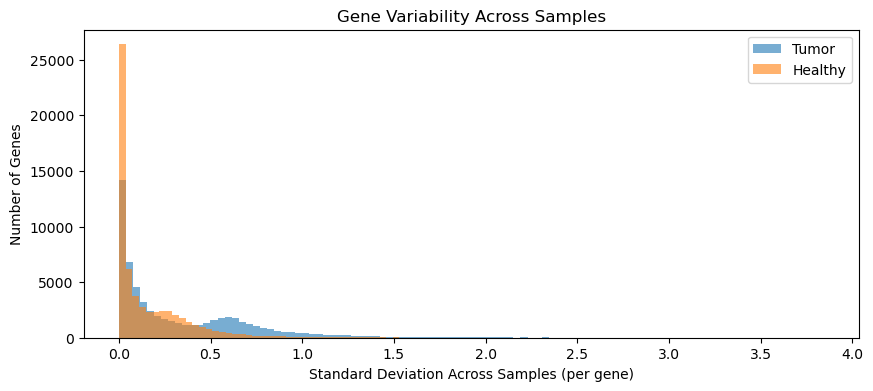

In [37]:
# Standard deviation across genes 
tumor_gene_std = tcga_tumor_df.std(axis=1)
healthy_gene_std = tcga_healthy_df.std(axis=1)

plt.figure(figsize=(10,4))
plt.hist(tumor_gene_std, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_gene_std, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Standard Deviation Across Samples (per gene)")
plt.ylabel("Number of Genes")
plt.title("Gene Variability Across Samples")
plt.legend()
plt.show()

### PCA to see diversity among all tumor samples 

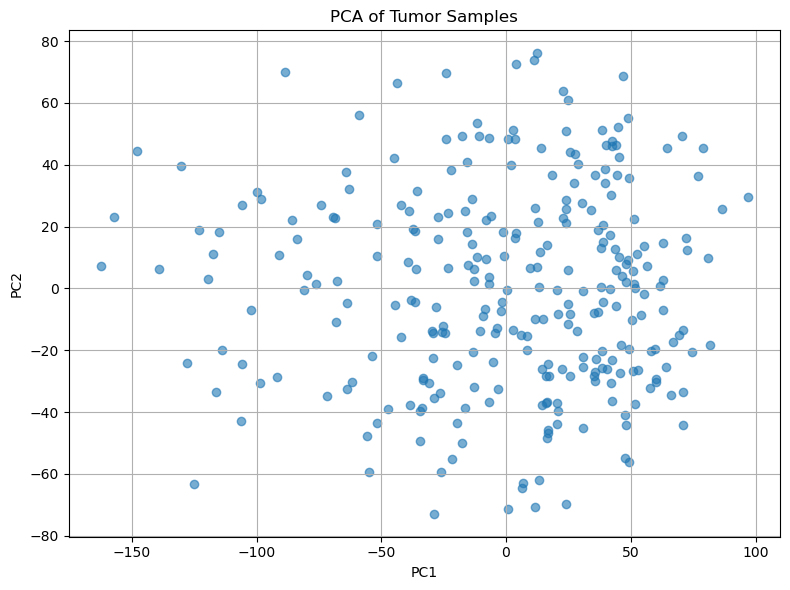

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
tumor_data = tcga_tumor_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tumor_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Tumor Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### PCA to see diversity among all healthy samples 

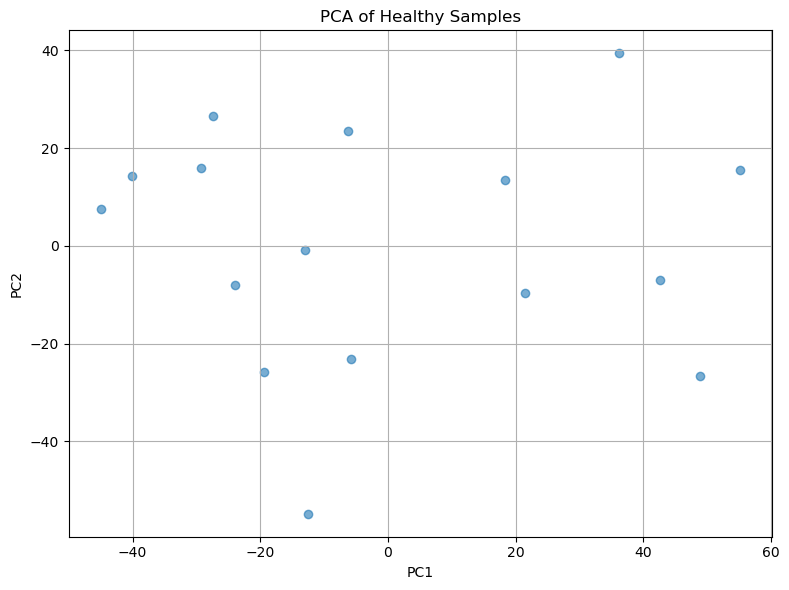

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
healthy_data = tcga_healthy_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(healthy_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Healthy Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

# Density and Ambiguity plots 

In [43]:
# Desnsity plot of al TPM values in the data (All genes x )
# Flattening data 
tpm_values = tcga_only.values.flatten()

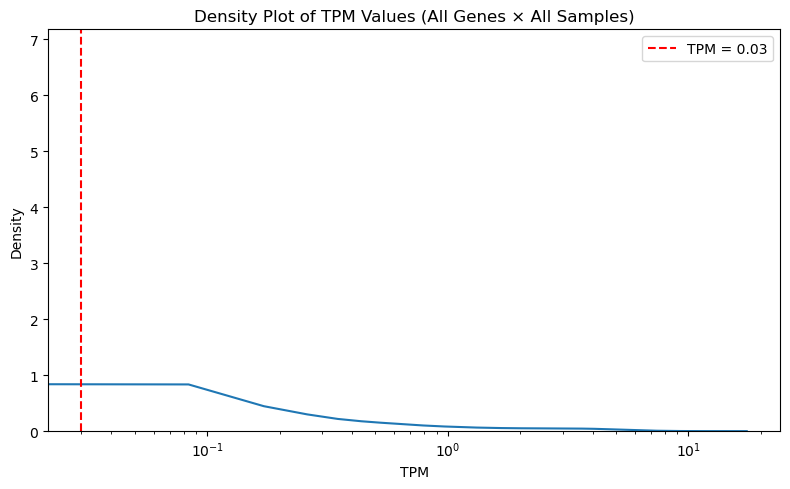

In [44]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_values, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
plt.xscale('log') 
plt.legend()
plt.tight_layout()
plt.show()

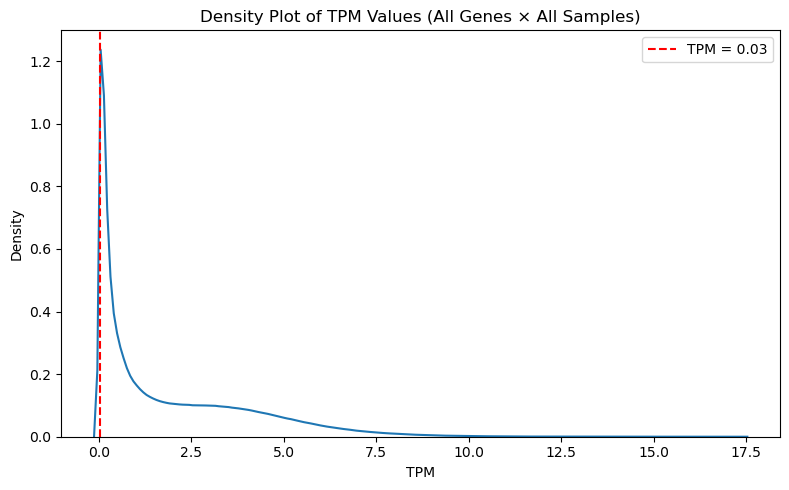

In [45]:
# Density plot, filtering values = 0 or negatives if they exist 
tpm_threshold_value = tpm_values[tpm_values > 0]

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_threshold_value, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
#plt.xscale('log')  
plt.legend()
plt.tight_layout()
plt.show()

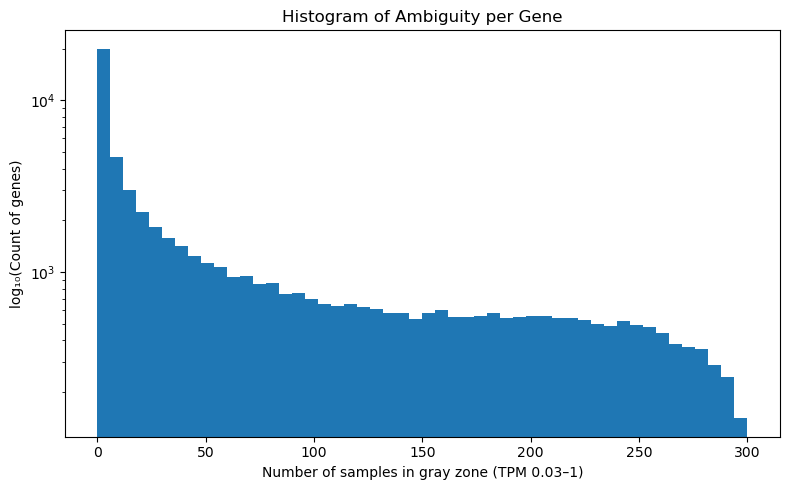

In [46]:
# Histogram of ambiguity per gene 
# Define gray zone thresholds
lower_thresh = 0.03
upper_thresh = 1

# Count ambiguity per gene, samples in the grey zone
ambiguity_counts = tcga_only.apply(lambda row: ((row >= lower_thresh) & (row <= upper_thresh)).sum(), axis=1)

# Histogram (log scale on y-axis)
plt.figure(figsize=(8, 5))
plt.hist(ambiguity_counts, bins=50)
plt.yscale('log')
plt.title("Histogram of Ambiguity per Gene")
plt.xlabel("Number of samples in gray zone (TPM 0.03–1)")
plt.ylabel("log₁₀(Count of genes)")
plt.tight_layout()
plt.show()

In [47]:
print (ambiguity_counts)

Ensembl_ID
ENSG00000000003      0
ENSG00000000005    174
ENSG00000000419      0
ENSG00000000457      0
ENSG00000000460     40
                  ... 
ENSG00000288669     43
ENSG00000288670      0
ENSG00000288671      0
ENSG00000288674    212
ENSG00000288675    275
Length: 60660, dtype: int64


# Full set & 90 ambiguity pure, (Tumor and healhty each)

#### Picking genes with at least 90% pure of ambiguity values 
Will clear noisy genes and retain a clean mayority。

In [50]:
# Number of samples
n_samples = tcga_only.shape[1]

# Defining ambiguity theshold (70% of total sample count)
max_ambigous = int(n_samples * 0.70)

In [51]:
# Ambiguity filter 
# Mask for genes with <= 70% ambiguity
keep_genes_mask = ambiguity_counts <= max_ambigous 

# Applying 
less_ambigous_tcga = tcga_only.loc[keep_genes_mask]

In [52]:
# Check how many genes remain
print(f"Original genes: {tcga_only.shape[0]}")
print(f"Filtered genes: {less_ambigous_tcga.shape[0]}")

Original genes: 60660
Filtered genes: 54445


### No filering , full ambigous

In [54]:
full_ambigous = tcga_only.copy()
print(f"Full ambigous genes: {full_ambigous.shape[0]}")

Full ambigous genes: 60660


# Discrete Model
Row-wise 25th/75th percentile to +-1/0, assigning per-sample ±1/0/–1 labels with the 25ᵗʰ/75ᵗʰ-percentile rule

In [56]:
# Discreatizing function 
def discretize_row(row): 
    q25 = row.quantile(0.25)
    q75 = row.quantile(0.75)
    return row.apply(lambda x : 1 if x >= q75 else ( -1 if x <= q25 else 0 ) )

### Discretising for less ambigous 

In [58]:
# applying function
tcga_discrete = less_ambigous_tcga.apply(discretize_row, axis=1)
print(f"Less ambigous genes: {tcga_discrete.shape[0]}")

Less ambigous genes: 54445


### Discreising for full ambigous

In [60]:
# applying function
tcga_discrete_ambigous = full_ambigous.apply(discretize_row, axis=1)
print(f"Full ambigous genes: {tcga_discrete_ambigous.shape[0]}")

Full ambigous genes: 60660


### Spliting main data to tumor and healthy

In [62]:
# Less ambigous
tcga_tumor   = tcga_discrete.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy = tcga_discrete.loc[:, tcga_only.columns.str.contains("Healthy")]

# Full ambigous
tcga_tumor_amb   = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_amb = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Healthy")]

### Collapsing Datasets for iMat

Collapsing to one vector each tcga dataframe , same approach used by FASTCORMICS :
- If ≥90% of samples have +1 ----> final value = +1
- If ≥90% of samples have -1 ----> final value = -1
- Else ----> final value = 0

In [64]:
# Fascormics function like
def collapse_by_voting(df):
    def vote(row):
        total = len(row)
        count_pos = (row == 1).sum()
        count_neg = (row == -1).sum()
        if count_pos / total >= 0.7:
            return 1
        elif count_neg / total >= 0.7:
            return -1
        else:
            return 0
    return df.apply(vote, axis=1)

In [65]:
# Applying fucntion less ambigous 
tumor_vector = collapse_by_voting(tcga_tumor)
healthy_vector = collapse_by_voting(tcga_healthy)

In [66]:
# Applying fucntion full ambigous 
tumor_vector_amb = collapse_by_voting(tcga_tumor_amb)
healthy_vector_amb = collapse_by_voting(tcga_healthy_amb)

### Visual exploration of the data 

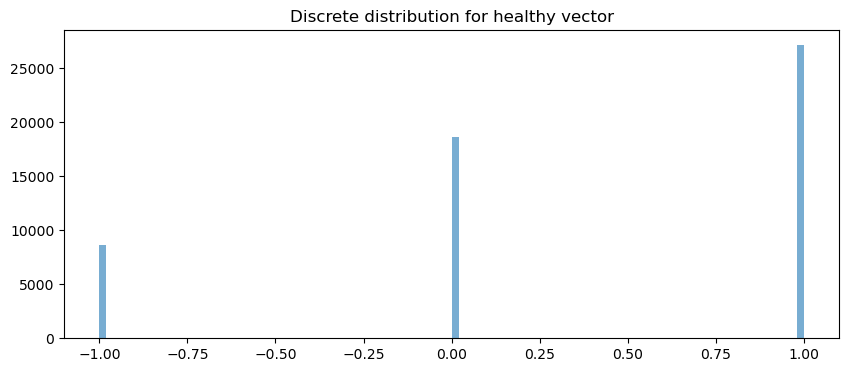

In [68]:
# Data visualization for Healhty less ambigous
plt.figure(figsize=(10,4))
plt.hist(healthy_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector")
plt.show()

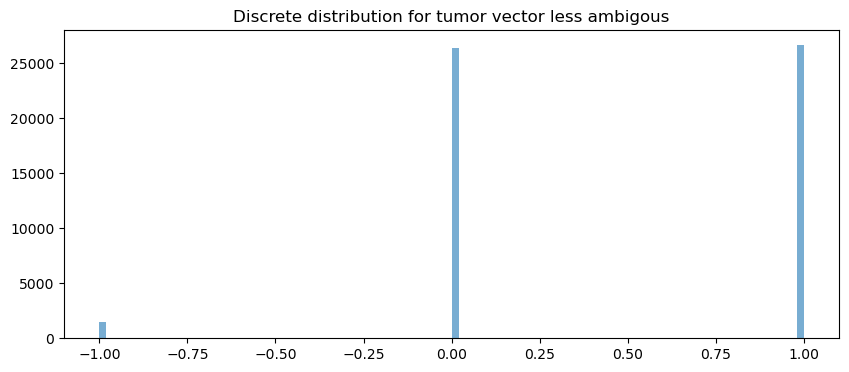

In [69]:
# Data visualization for tumor less ambigous

plt.figure(figsize=(10,4))
plt.hist(tumor_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector less ambigous")
plt.show()

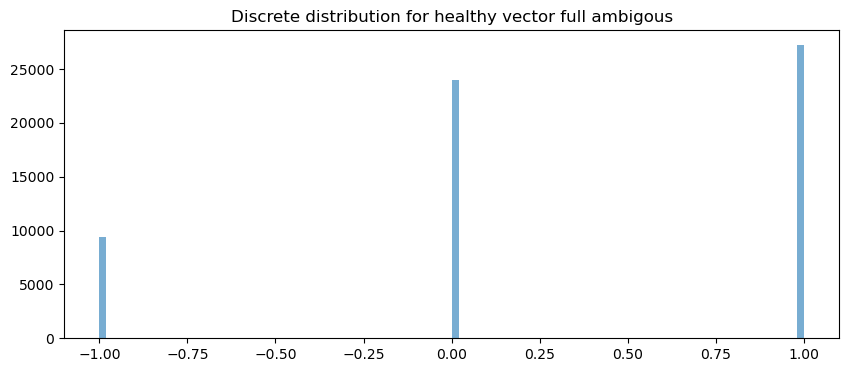

In [70]:
# Data visualization for Healhty full ambigous

plt.figure(figsize=(10,4))
plt.hist(healthy_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector full ambigous")
plt.show()

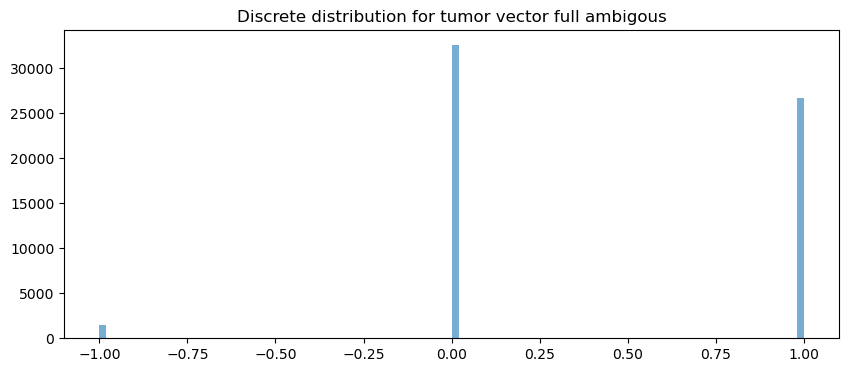

In [71]:
# Data visualization for tumor full ambigous
plt.figure(figsize=(10,4))
plt.hist(tumor_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

Data needs to be formated to be suitable for matlab

In [73]:
# Reformating 
#For tumor 
tumor_vector_df = tumor_vector.reset_index()
tumor_vector_df.columns = ['GeneID', 'Expression']

tumor_vector_amb_df = tumor_vector_amb.reset_index()
tumor_vector_amb_df.columns = ['GeneID', 'Expression']

#For healthy
healthy_vector_df = healthy_vector.reset_index()
healthy_vector_df.columns = ['GeneID', 'Expression']

healthy_vector_amb_df = healthy_vector_amb.reset_index()
healthy_vector_amb_df.columns = ['GeneID', 'Expression']


In [74]:
# Exporting values 
tumor_vector_df.to_csv("tumor_expression_vector70.txt", sep="\t", index=False, header=False)
healthy_vector_df.to_csv("healthy_expression_vector70.txt", sep="\t", index=False, header=False)

tumor_vector_amb_df.to_csv("tumor_expression_vector_full.txt", sep="\t", index=False, header=False)
healthy_vector_amb_df.to_csv("healthy_expression_vector_full.txt", sep="\t", index=False, header=False)


# Continuous Models 

In [76]:
print(f"Full ambigous genes: {full_ambigous.shape[0]}")
print(full_ambigous.isna().sum().sum())

Full ambigous genes: 60660
0


In [77]:
print(f"Less ambigous genes: {less_ambigous_tcga.shape[0]}")
print(less_ambigous_tcga.isna().sum().sum())

Less ambigous genes: 54445
0


In [78]:
# Spliting datasets 
# Less ambigous
tcga_cont_Ambfiltered_tumor   = less_ambigous_tcga.loc[:, less_ambigous_tcga.columns.str.contains("Tumor")]
tcga_cont_Ambfiltered_healthy = less_ambigous_tcga.loc[:, less_ambigous_tcga.columns.str.contains("Healthy")]

# Full ambigous
tcga_cont_full_tumor   = full_ambigous.loc[:, full_ambigous.columns.str.contains("Tumor")]
tcga_cont_full_healthy = full_ambigous.loc[:, full_ambigous.columns.str.contains("Healthy")]

## Median method

In [80]:
# Calculating median across both datasets full ambigous and less 
# Less ambigous 
tcga_Ambfilt_cont_healthy_median = tcga_cont_Ambfiltered_healthy.median(axis=1)
tcga_Ambfilt_cont_tumor_median = tcga_cont_Ambfiltered_tumor.median(axis=1)

# Full ambigous 
tcga_full_cont_healthy_median = tcga_cont_full_healthy.median(axis=1)
tcga_full_cont_tumor_median = tcga_cont_full_tumor.median(axis=1)

## Data visualization 

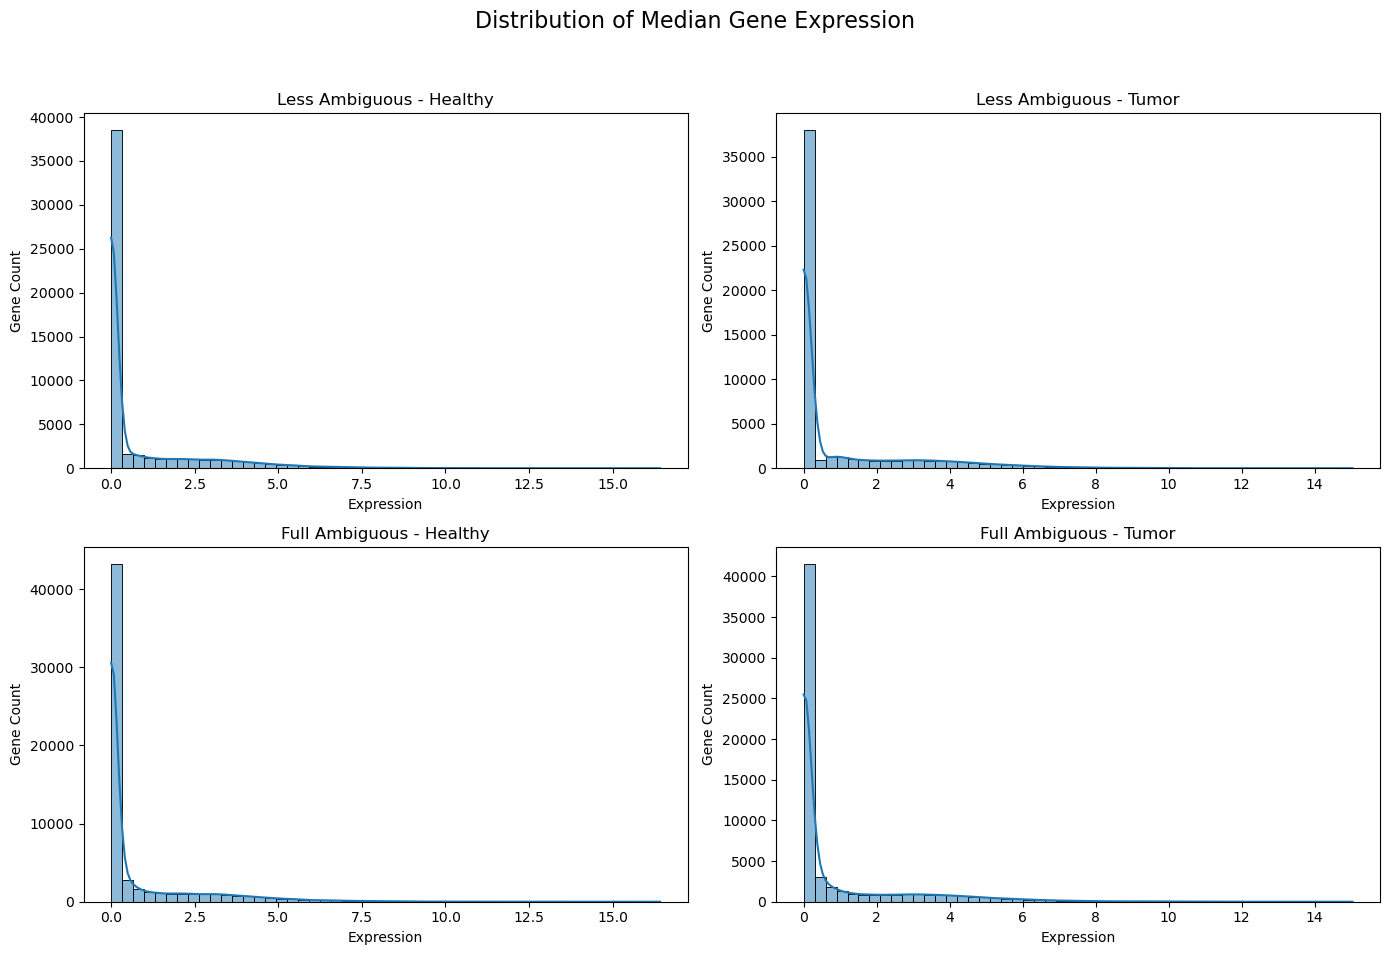

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Median Gene Expression", fontsize=16)

# Top-left
sns.histplot(tcga_Ambfilt_cont_healthy_median, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Less Ambiguous - Healthy")
axes[0, 0].set_xlabel("Expression")
axes[0, 0].set_ylabel("Gene Count")

# Top-right
sns.histplot(tcga_Ambfilt_cont_tumor_median, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Less Ambiguous - Tumor")
axes[0, 1].set_xlabel("Expression")
axes[0, 1].set_ylabel("Gene Count")

# Bottom-left
sns.histplot(tcga_full_cont_healthy_median, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Full Ambiguous - Healthy")
axes[1, 0].set_xlabel("Expression")
axes[1, 0].set_ylabel("Gene Count")

# Bottom-right
sns.histplot(tcga_full_cont_tumor_median, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Full Ambiguous - Tumor")
axes[1, 1].set_xlabel("Expression")
axes[1, 1].set_ylabel("Gene Count")

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exporting data 

In [84]:
# Reformating 
#For Full data 
tcga_full_continuous_tumor_median = tcga_full_cont_tumor_median.reset_index()
tcga_full_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_full_continuous_healthy_median = tcga_full_cont_healthy_median.reset_index()
tcga_full_continuous_healthy_median.columns = ['GeneID', 'Expression']

#For less ambigous
tcga_less_continuous_tumor_median = tcga_Ambfilt_cont_tumor_median.reset_index()
tcga_less_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_less_continuous_healthy_median = tcga_Ambfilt_cont_healthy_median.reset_index()
tcga_less_continuous_healthy_median.columns = ['GeneID', 'Expression']


In [85]:
# Exporting values 
# Full data
#tcga_full_continuous_tumor_median.to_csv("tumor_full_cont_vector.txt", sep="\t", index=False, header=False)
#tcga_full_continuous_healthy_median.to_csv("healthy__full_cont_vector.txt", sep="\t", index=False, header=False)

# Less ambigous
#tcga_less_continuous_tumor_median.to_csv("tumor_Ambfilt_cont_vector.txt", sep="\t", index=False, header=False)
#tcga_less_continuous_healthy_median.to_csv("healthy_Ambfilt_cont_vector.txt", sep="\t", index=False, header=False)

# List your biomass gene IDs
biomass_genes = ["ENSG00000115275", "ENSG00000110436", ...]  # example

# See how they score under your median vector
biomass_expr = tcga_full_cont_tumor_median.loc[tcga_full_cont_tumor_median.index.isin(biomass_genes)]
print(biomass_expr.sort_values())

Ensembl_ID
ENSG00000110436    1.644044
ENSG00000115275    5.906241
dtype: float64


# Z score Column wise

In [181]:
# Column-wise Z-score normalization (within each sample)
z_scores = (tcga_only - tcga_only.mean(axis=0)) / tcga_only.std(axis=0)

In [183]:
# Binarizing 
z_bin = z_scores.copy()

# Binarize: +1, -1, 0
z_bin[z_scores >= 0.5] = 1
z_bin[z_scores <= -0.5] = -1
z_bin[(z_scores > -0.5) & (z_scores < 0.5)] = 0

In [195]:
# Split normalized data into tumor and healthy samples
z_tumor = z_bin.loc[:, z_scores.columns.str.contains("Tumor")]
z_healthy = z_bin.loc[:, z_scores.columns.str.contains("Healthy")]

In [198]:
# Applyting FastComics logic 
def fastcomics_vote(row, threshold=0.6):
    total = len(row)
    pos_count = (row == 1).sum()
    neg_count = (row == -1).sum()
    
    if pos_count / total >= threshold:
        return 1
    elif neg_count / total >= threshold:
        return -1
    else:
        return 0

z_tumor_vector = z_tumor.apply(fastcomics_vote, axis=1)
z_healthy_vector = z_healthy.apply(fastcomics_vote, axis=1)

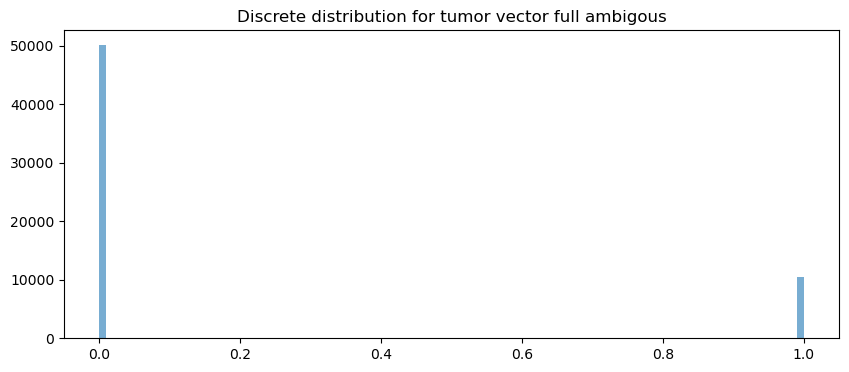

In [202]:
plt.figure(figsize=(10,4))
plt.hist(z_healthy_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

In [208]:
#Prepare vectors for export to MATLAB 
zscore_output_tumor = pd.DataFrame({
    'GeneID': tcga_only.index,
    'Expression': z_tumor_vector
})

zscore_output_healthy = pd.DataFrame({
    'GeneID': tcga_only.index,
    'Expression': z_healthy_vector
})

In [216]:
# Step 6: Export for MATLAB 

# Export tumor data
zscore_output_tumor.to_csv("Zscore_vector_tumor.txt", sep="\t", index=False, header=False)

# Export healthy data
zscore_output_healthy.to_csv("Zscore_vector_healthy.txt", sep="\t", index=False, header=False)